In [35]:
# импортируем библиотеки
import keras
from keras.layers import Dense
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
classification_data = [      #датасет нашей нейронки
    [1, 1, 1, 1],
    [1, 1, 0, 1],
    [1, 0, 1, 0],
    [1, 0, 0, 0],
    [0, 1, 1, 1],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 0],
    [1, 1, 1, 1],
    [1, 1, 0, 1],
    [1, 0, 1, 0],
    [0, 1, 1, 1],
    [0, 0, 0, 0]
]
X_cls = np.array(classification_data)[:, :3] #x - входные данные
y_cls = np.array(classification_data)[:, 3] #y - выходные данные

In [ ]:
model = keras.Sequential() # собираем нейронную сеть 
model.add(Dense(3, activation="tanh", input_dim=3))
model.add(Dense(5, activation="tanh"))
model.add(Dense(1, activation="sigmoid")) 

print(model.summary()) # Выводим структуру нейросетки, и смотрим сколько
                         #всего в нём параметров 

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_52 (Dense)                │ (None, 3)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_53 (Dense)                │ (None, 5)              │            20 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_54 (Dense)                │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38 (152.00 B)

 Trainable params: 38 (152.00 B)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
#компилуреем модель(определяем оптимизатор, ф-цию потерь)
model.compile(loss="binary_crossentropy", metrics=['accuracy'], optimizer='adam')

In [ ]:
history = model.fit(X_cls, y_cls, batch_size=16, epochs=50) #обучаем

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.6154 - loss: 0.6980
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.6154 - loss: 0.6969
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6154 - loss: 0.6958
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6154 - loss: 0.6947
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6154 - loss: 0.6937
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6154 - loss: 0.6926
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6154 - loss: 0.6915
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.6154 - loss: 0.6904
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - accuracy: 0.6154 - loss: 0.6894
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 0.6154 - loss: 0.6883
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6154 - loss: 0.6872
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.6154 - loss: 0.6862
Epo

In [ ]:
no_criminal_record = int(input())
sane = int(input())
education = int(input())
prediction = model.predict(np.array([[no_criminal_record, sane, education]]))
e = np.round(prediction)
print(e) #нейросеть счиитает результат(предсказывает)

1
1
1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
[[1.]]


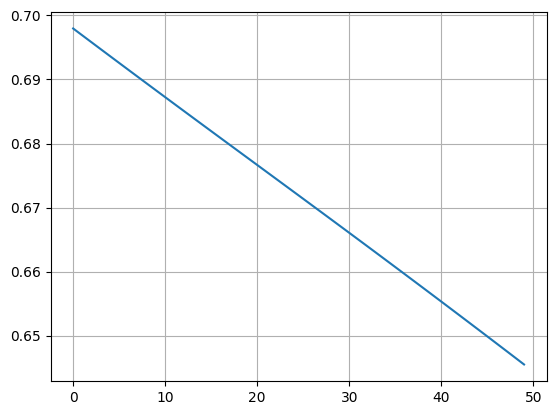

In [ ]:
plt.plot(history.history['loss'])
plt.grid(True)
plt.show() #выводим график потерь

In [ ]:
model.save('work_NS.keras') #сохраняем нашу модель